# **ΟΜΑΔΑ ΕΡΓΑΣΙΑΣ 3 - Ερώτηση 2**
*   Δημούδης Γεώργιος 5212
*   Στρούγγης Γεώργιος 5357

In [ ]:
#Cells are expected to be run in order as seen. Thank you.

import pandas as pd
import scipy.sparse as sp
import sklearn as sk
import matplotlib.pyplot as plt
import ast
from collections import Counter

In [46]:
#create dataframes for all three csv files
movie_df = pd.read_csv("movies_metadata.csv", usecols=["id", "genres","revenue"], on_bad_lines="skip")
rating_df = pd.read_csv("ratings_small.csv", usecols=["userId","movieId","rating"], on_bad_lines="skip")
link_df = pd.read_csv("links_small.csv", usecols=["movieId"], on_bad_lines="skip")

#merges link and rating dataframes into a temp_df
#converts the "id" column in the movie dataframe to "movieId"
#converts the "movieId" column in the temp_df and movie dataframes to string so that they are compatible and then merges them
temp_df = pd.merge(link_df,rating_df,on="movieId")
movie_df = movie_df.rename(columns={"id":"movieId"})
temp_df.movieId = temp_df.movieId.astype("string")
movie_df.movieId = movie_df.movieId.astype("string")
df = pd.merge(temp_df,movie_df,on="movieId")

#using the merged df, creates a dataframe with only the movie ids and ratings, groups by the movie ids and keeps only the ones that have 10 or more movies
#https://stackoverflow.com/questions/17945247/get-size-of-a-group-knowing-its-grouper-id-in-pandas-groupby
df_grouped = df[["movieId","rating"]]
df_grouped = df_grouped.groupby("movieId")
df_size = df_grouped.size()
df_size = df_size[df_size >= 10]

#removes all the rows from our main dataframe that are not in the grouped dataframe, aka only those that have at least 10 movies
#the reason this couldn't be done directly in our main df is because the other columns besides movie ids and ratings overcomplicated the otherwise simple process
df = df[df['movieId'].isin(df_size.index)]

#assigns new ids to the users and movies
#we do this because the ids are too spread out, creating a huge matrix with lot of blank lines full of zeroes that make k-means much slower and give much poorer results
#with this we have a smaller arrangement of ids that runs faster and has better results
df['userId_new'], _ = pd.factorize(df['userId'])
df['movieId_new'], _ = pd.factorize(df['movieId'])

#creates a sparse matrix with the ratings and the new ids
sparse_data = sp.csr_matrix((df["rating"].tolist(), (df["movieId_new"].tolist(),df["userId_new"].tolist())), shape=(max(df["movieId_new"].tolist())+1, max(df["userId_new"].tolist())+1))

In [ ]:
#K-means
#for range 2 to 20 we find the Sum of Squares Error and Silhouette Coefficient and keep them in a list
k_values = range(2,21)
SSE = []
silhouette_coeffs = []

for k in k_values:
  kmeans = sk.cluster.KMeans(init='k-means++', n_clusters=k, max_iter=100)
  kmeans.fit_predict(sparse_data)
  error = kmeans.inertia_
  SSE.append(error)

  score = sk.metrics.silhouette_score(sparse_data, kmeans.labels_)
  silhouette_coeffs.append(score)

  print(f"K = {k}")
  print(f"Sum of Squares Error = {error}")
  print(f"Silhouette Coefficient = {score}\n")

K = 2
Sum of Squares Error = 436524.21453755634
Silhouette Coefficient = 0.36865075131798825

K = 3
Sum of Squares Error = 420798.79914378695
Silhouette Coefficient = 0.29615327626305227

K = 4
Sum of Squares Error = 409230.554253104
Silhouette Coefficient = 0.13351920154503455

K = 5
Sum of Squares Error = 402980.05797610886
Silhouette Coefficient = 0.1402761490158835

K = 6
Sum of Squares Error = 397501.27402368357
Silhouette Coefficient = 0.15150102920517666

K = 7
Sum of Squares Error = 394683.85907664214
Silhouette Coefficient = 0.1427610556999311

K = 8
Sum of Squares Error = 387661.3760781109
Silhouette Coefficient = 0.10235302703355059

K = 9
Sum of Squares Error = 382659.83365786914
Silhouette Coefficient = 0.11515839061153879

K = 10
Sum of Squares Error = 385324.0838221314
Silhouette Coefficient = 0.16525152610572902

K = 11
Sum of Squares Error = 375361.09010843356
Silhouette Coefficient = 0.04419905660776693

K = 12
Sum of Squares Error = 374503.9066995113
Silhouette Coeff

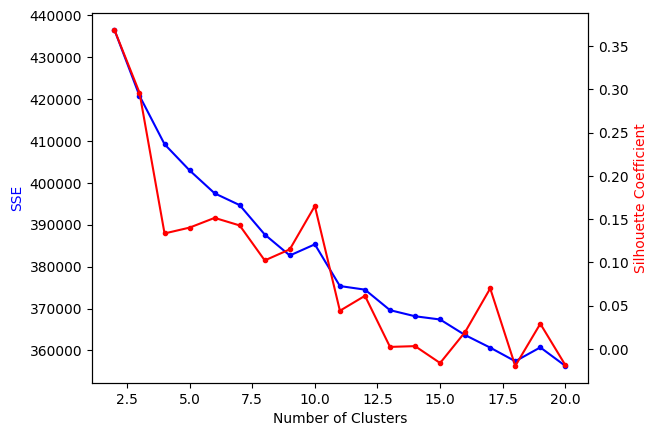

In [ ]:
#plots the SSE and Silhouette Coefficient scores in the same plot
fig, ax1 = plt.subplots()

ax1.set_xlabel("Number of Clusters")
ax1.set_ylabel("SSE", color="blue")
ax1.plot(k_values, SSE, color="blue", marker='.')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Coefficient', color='red')
ax2.plot(k_values, silhouette_coeffs, color='red', marker='.')

plt.show()

#SSE measures how close each point is to the centre of its cluster, indicating how compact a cluster is
#there is no universal "good" value for SSE and it's largely dependent on the specific data
#in that regard, we know that lower values are generally better and here the higher k values consistently decrease the error
#at lower values the error starts at 440K while at higher values it can decrease to around 350K, showing just how significant of a difference the k values make
#however, it should be noted that with a higher k value, decrease is actually unavoidable so it's not necessarily indicative of quality

#Silhouette Coefficient values range from -1 to +1 and indicate how well a point fits its assigned cluster
#negative values mean the assignment is wrong, values near 0 are mediocre and positive balues close to 1 indicate its well placed within its own cluster
#here we observe the opposite of SSE, the more that k increases the worse the score gets, starting from 0.35 which would be good to around 0 which indicates poor performance
#we also observe that it's a lot less consistent than SSE as it experiences spikes of improvement, even though it generally decreases with higher values

#it's difficult to select an appropriate k value due to the conflicting results, whereas SSE measures closeness to the centre of a cluster, SC measures if it correctly belongs to that cluster
#in the end we have chosen to prioritize SC over SSE because as we said above, decrease in SSE as k rises is unavoidable
#that means lower k values will be more optimal, 2 or 3 to strike whatever balance we can

In [ ]:
#Agglomerative Clustering
#applying the agglomerative clustering algorithm, we measure how many movies are assigned to each cluster and store them in a dict
#https://www.geeksforgeeks.org/machine-learning/implementing-agglomerative-clustering-using-sklearn/
for k in k_values:
  cluster_dict = {i: 0 for i in range(k)}
  model = sk.cluster.AgglomerativeClustering(n_clusters=k)
  agg_cluster = model.fit_predict(sparse_data.toarray())
  for i in agg_cluster:
    if i in cluster_dict:
      cluster_dict[i] += 1
    else:
      cluster_dict[i] = 1

  print(f"K = {k}")
  print(cluster_dict)

#the more clusters we use then the further the movies are distributes among them
#this makes sense as more clusters allows for it to get more 'particular' with classification, perhaps too much as for higher values we also get clusters in the single digits
#even so, we can observe clusters with up to three digits even at high k values, which implies high cohesion for certain clusters that stick together even then
#comparing it to k-means, it seems that a low-to-medium level of clusters is most acceptable here so that we neither lump too many movies up nor spread them out too much
#this partly aligns with our choice of k=2 or 3 for k-means, but that might be too narrow for agglomerative clustering
#across the board, we conclude that 2-5 might be the ideal number of clusters across the board for both algorithms
#this is to avoid clusters with movies in the single digits, as by that point we aren't finding genres but outliers

K = 2
{0: 340, 1: 612}
K = 3
{0: 307, 1: 612, 2: 33}
K = 4
{0: 262, 1: 45, 2: 33, 3: 612}
K = 5
{0: 33, 1: 45, 2: 185, 3: 612, 4: 77}
K = 6
{0: 185, 1: 45, 2: 29, 3: 612, 4: 77, 5: 4}
K = 7
{0: 45, 1: 612, 2: 29, 3: 124, 4: 77, 5: 4, 6: 61}
K = 8
{0: 612, 1: 24, 2: 29, 3: 124, 4: 77, 5: 4, 6: 61, 7: 21}
K = 9
{0: 24, 1: 124, 2: 29, 3: 484, 4: 77, 5: 4, 6: 61, 7: 21, 8: 128}
K = 10
{0: 124, 1: 11, 2: 29, 3: 484, 4: 77, 5: 4, 6: 61, 7: 21, 8: 128, 9: 13}
K = 11
{0: 29, 1: 11, 2: 61, 3: 484, 4: 77, 5: 4, 6: 99, 7: 21, 8: 128, 9: 13, 10: 25}
K = 12
{0: 61, 1: 11, 2: 4, 3: 484, 4: 77, 5: 11, 6: 99, 7: 21, 8: 128, 9: 13, 10: 25, 11: 18}
K = 13
{0: 11, 1: 484, 2: 4, 3: 45, 4: 77, 5: 11, 6: 99, 7: 21, 8: 128, 9: 13, 10: 25, 11: 18, 12: 16}
K = 14
{0: 484, 1: 45, 2: 4, 3: 3, 4: 77, 5: 11, 6: 99, 7: 21, 8: 128, 9: 13, 10: 25, 11: 18, 12: 16, 13: 8}
K = 15
{0: 45, 1: 77, 2: 4, 3: 3, 4: 13, 5: 11, 6: 99, 7: 21, 8: 128, 9: 185, 10: 25, 11: 18, 12: 16, 13: 8, 14: 299}
K = 16
{0: 77, 1: 13, 2: 4, 3: 

In [ ]:
#Frequency
#keeps dataframe of movie ids and genres, also filters out the unnecessary text from the genres column to just keep a list of their names
genres_and_ids = df[['movieId_new','genres']]
for index, row in genres_and_ids.iterrows():
  temp = []
  text = row['genres']
  text = ast.literal_eval(text)
  if len(text) != 0:
    for i in range(len(text)-1):
      temp.append(text[i]["name"])
  genres_and_ids.at[index, 'genres'] = temp
genres_and_ids = genres_and_ids.dropna()

#runs Agglomerative Clustering for 5 clusters as we said in the previous cell
cluster_dict = {i: [] for i in range(5)}
model = sk.cluster.AgglomerativeClustering(n_clusters=5)
agg_cluster = model.fit_predict(sparse_data.toarray())

#creates a dictionary where for every cluster it collects the genres of the movies in it
for i in range(0,len(agg_cluster)-1):
  cluster_dict[agg_cluster[i]].append(genres_and_ids[genres_and_ids["movieId_new"] == i]["genres"].iloc[0])

#fuses all the lists into one list for each cluster, each containing multiple instances of a genre
#exchanges the list into a dictionary containing a count of every movie of a specific genre for that cluster
#in the end we have a dictionary for each cluster in which we keep dictionaries of the genres in them
#we also keep the total number of movies in each cluster to measure the percentage of them that any given genre takes up
for k in range(5):
  temp_list = []
  for j in list(cluster_dict[k]):
    temp_list += j
  cluster_dict[k] = temp_list
  temp_dict = {}
  for i in cluster_dict[k]:
    if i not in temp_dict:
      temp_dict[i] = 1
    else:
      temp_dict[i] += 1
  cluster_dict[k] = temp_dict
  print(f"Cluster {k}")
  print(cluster_dict[k])

  total = sum(cluster_dict[k].values())
  print("Percentages:")
  for genre, count in cluster_dict[k].items():
    print(f"{genre}: {count / total}")
  print()

#what we can assess from this is that most clusters contain a variety of different movies in them in comparable frequencies
#it seems that Dramas are by and large the most popular genre, with Action, Comedy and Crime movies having large percentages though not as much as Dramas
#however it is odd that genres are pretty spread out across the board and in multiple clusters
#a possible explanation for this is that since movies can have multiple genres, a lot of these other genres of lesser frequencies are secondary genres to the same movies that are also labeled as Dramas

Cluster 0
{'Drama': 11, 'Mystery': 1, 'Thriller': 3, 'Action': 5, 'Comedy': 7, 'Crime': 5, 'Adventure': 5, 'Family': 1, 'Science Fiction': 2, 'Documentary': 1, 'Horror': 2, 'Fantasy': 1, 'Romance': 1}
Percentages:
Drama: 0.24444444444444444
Mystery: 0.022222222222222223
Thriller: 0.06666666666666667
Action: 0.1111111111111111
Comedy: 0.15555555555555556
Crime: 0.1111111111111111
Adventure: 0.1111111111111111
Family: 0.022222222222222223
Science Fiction: 0.044444444444444446
Documentary: 0.022222222222222223
Horror: 0.044444444444444446
Fantasy: 0.022222222222222223
Romance: 0.022222222222222223

Cluster 1
{'Action': 8, 'Crime': 7, 'Drama': 13, 'Thriller': 4, 'Adventure': 4, 'Comedy': 9, 'Mystery': 2, 'Fantasy': 3, 'Horror': 1, 'Science Fiction': 1, 'Western': 1, 'History': 1, 'Documentary': 1}
Percentages:
Action: 0.14545454545454545
Crime: 0.12727272727272726
Drama: 0.23636363636363636
Thriller: 0.07272727272727272
Adventure: 0.07272727272727272
Comedy: 0.16363636363636364
Mystery: 0.

In [ ]:
#to find the lift, we first create a dictionary that contains the total number of movies in each genre across all clusters
#https://stackoverflow.com/questions/11011756/is-there-any-pythonic-way-to-combine-two-dicts-adding-values-for-keys-that-appe
total_dict = Counter({})
for k in range(5):
  temp = Counter(cluster_dict[k])
  total_dict += temp

#we copy the dict so we can have an identical dictionary that will later be modified
cluster_dict2 = cluster_dict.copy()

#then we go into each cluster and each genre in the cluster and calculate the lift
#lift is calculated by dividing the word frequency in a cluster (cluster_dict[k][i]) with the total number of movies in the cluster (sum(cluster_dict[k].values()))
#then we divide the total number of movies in a genre (total_dict[i])) with the total number of movies (sum(total_dict.values()))
#then we divide the values we got from these to get the lift
#using the copied dict, we replace the values with the lift for convenience
#finally, we sort the genres by their values and then print the top 3 genres with the highest values for each cluster
for k in range(5):
  for i in cluster_dict[k]:
    lift = (cluster_dict[k][i]/sum(cluster_dict[k].values()))/(total_dict[i]/sum(total_dict.values()))
    cluster_dict2[k][i] = lift
  print(f"Cluster {k}")
  print(sorted(cluster_dict2[k].items(), key=lambda item: item[1])[-3:])

#higher lift values of 1 or higher imply that the presence of a genre within a cluster exceeds expectations, whereas values below 1 means less often
#we can assess that each cluster seems to group together different genres than the other
#even if the total number of movies for each genre is low, their presence within a cluster is significant due to the way lift is calculated
#as opposed to that, genres with plenty of movies that are spread out across all clusters are less significant because they are so common and prevalent
#it's as we said above, sometimes movies have multiple genres that are secondary compared to their primary genre, lots of movies may be labeled as dramas but that is not their core identifying chaarcteristic
#this also means that assessing the lift is a superior method to checking the frequencies
#as we saw in the previous cell frequencies just told us the same thing: Dramas dominate, so using lift provides more useful information
#in conclusion, we consider this effective clustering due to zeroing in on the importance of a genre's presence within a cluster compared to the whole
#as a side note, if the values seem a littlee big there is a logical explanation for that, if there are only a few movies of a specific genre in total then a cluster having all or most of them is very important, much more than having more movies of a more widespread genre

Cluster 0
[('Science Fiction', 2.2079400498937884), ('Adventure', 2.6532255685857686), ('Documentary', 3.5967086167902163)]
Cluster 1
[('Fantasy', 2.1825801319968274), ('Mystery', 2.492106080089445), ('Western', 5.202205019573114)]
Cluster 2
[('Animation', 2.1931558894597893), ('Romance', 3.1469922559615817), ('Music', 4.3000989295508685)]
Cluster 3
[('War', 2.764666423858881), ('Foreign', 5.512765914541017), ('TV Movie', 6.779267084918476)]
Cluster 4
[('Adventure', 2.058940333750719), ('Family', 2.4247898167535924), ('Animation', 5.135712216542646)]


#**PCA**

In [ ]:
#create PCA model and create the matrix from our sparse data
pca = sk.decomposition.PCA(n_components=50)
matrix = pca.fit_transform(sparse_data)

#run the same process as above with new data
k_values = range(2,21)
SSE = []
silhouette_coeffs = []

for k in k_values:
  kmeans = sk.cluster.KMeans(init='k-means++', n_clusters=k, max_iter=100)
  kmeans.fit_predict(matrix)
  error = kmeans.inertia_
  SSE.append(error)

  score = sk.metrics.silhouette_score(matrix, kmeans.labels_)
  silhouette_coeffs.append(score)

  print(f"K = {k}")
  print(f"Sum of Squares Error = {error}")
  print(f"Silhouette Coefficient = {score}\n")

K = 2
Sum of Squares Error = 226999.2792026012
Silhouette Coefficient = 0.45978068616456547

K = 3
Sum of Squares Error = 211260.55696116746
Silhouette Coefficient = 0.40904531239389363

K = 4
Sum of Squares Error = 200028.38299031561
Silhouette Coefficient = 0.2174769998684987

K = 5
Sum of Squares Error = 196076.64104043494
Silhouette Coefficient = 0.21740523494455904

K = 6
Sum of Squares Error = 186232.85393764466
Silhouette Coefficient = 0.16051647988227574

K = 7
Sum of Squares Error = 180424.67774483594
Silhouette Coefficient = 0.15087829557526833

K = 8
Sum of Squares Error = 177086.01285639187
Silhouette Coefficient = 0.12214024624258155

K = 9
Sum of Squares Error = 173791.29671797875
Silhouette Coefficient = 0.1928531471561942

K = 10
Sum of Squares Error = 169929.0544521646
Silhouette Coefficient = 0.07025080607591282

K = 11
Sum of Squares Error = 166656.75618202647
Silhouette Coefficient = 0.04582222853660265

K = 12
Sum of Squares Error = 164040.05391139863
Silhouette Co

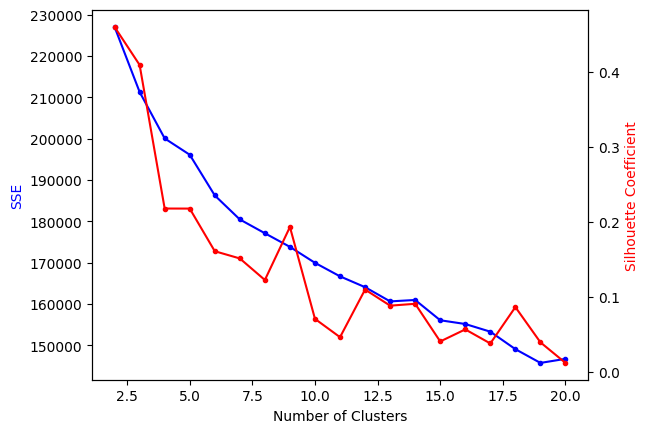

In [ ]:
fig, ax1 = plt.subplots()

ax1.set_xlabel("Number of Clusters")
ax1.set_ylabel("SSE", color="blue")
ax1.plot(k_values, SSE, color="blue", marker='.')

ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Coefficient', color='red')
ax2.plot(k_values, silhouette_coeffs, color='red', marker='.')

plt.show()

#we can detect immediate improvement on the Sum of Squares Error as it now ranged between 230K-140K
#in terms of the Silhouette Coefficient however, the scores remain just about the same
#what this tells us is that the reduction of features leads to closer distances between the points of a cluster, making them more compact
#however it does nothing to improve how much they fit the cluster
#in general terms our results are comparable if better due to the smaller error, as such we continue to believe that a smaller k value remains optimal

In [ ]:
for k in k_values:
  cluster_dict = {i: 0 for i in range(k)}
  model = sk.cluster.AgglomerativeClustering(n_clusters=k)
  agg_cluster = model.fit_predict(matrix)
  for i in agg_cluster:
    if i in cluster_dict:
      cluster_dict[i] += 1
    else:
      cluster_dict[i] = 1

  print(f"K = {k}")
  print(cluster_dict)
#even with PCA, the results of the Agglomerative Clustering remain similar, the more clusters we have the more 'particular' we get
#much like above, it is advisable to keep a smaller number of clusters to have a more consistent 'theme'
#in this case we'll pick 4 clusters to avoid clusters containing movies in the single digits

K = 2
{0: 96, 1: 856}
K = 3
{0: 856, 1: 39, 2: 57}
K = 4
{0: 39, 1: 207, 2: 57, 3: 649}
K = 5
{0: 207, 1: 649, 2: 57, 3: 34, 4: 5}
K = 6
{0: 649, 1: 171, 2: 57, 3: 34, 4: 5, 5: 36}
K = 7
{0: 171, 1: 602, 2: 57, 3: 34, 4: 5, 5: 36, 6: 47}
K = 8
{0: 602, 1: 34, 2: 57, 3: 61, 4: 5, 5: 36, 6: 47, 7: 110}
K = 9
{0: 57, 1: 34, 2: 207, 3: 61, 4: 5, 5: 36, 6: 47, 7: 110, 8: 395}
K = 10
{0: 44, 1: 34, 2: 207, 3: 61, 4: 5, 5: 36, 6: 47, 7: 110, 8: 395, 9: 13}
K = 11
{0: 34, 1: 61, 2: 207, 3: 33, 4: 5, 5: 36, 6: 47, 7: 110, 8: 395, 9: 13, 10: 11}
K = 12
{0: 61, 1: 5, 2: 207, 3: 33, 4: 13, 5: 23, 6: 47, 7: 110, 8: 395, 9: 11, 10: 11, 11: 36}
K = 13
{0: 5, 1: 33, 2: 207, 3: 45, 4: 13, 5: 23, 6: 47, 7: 110, 8: 395, 9: 11, 10: 11, 11: 36, 12: 16}
K = 14
{0: 33, 1: 45, 2: 207, 3: 395, 4: 13, 5: 23, 6: 47, 7: 110, 8: 4, 9: 11, 10: 11, 11: 36, 12: 16, 13: 1}
K = 15
{0: 45, 1: 13, 2: 207, 3: 395, 4: 11, 5: 23, 6: 47, 7: 110, 8: 4, 9: 11, 10: 11, 11: 36, 12: 16, 13: 1, 14: 22}
K = 16
{0: 207, 1: 13, 2: 23

In [ ]:
cluster_dict = {i: [] for i in range(4)}
model = sk.cluster.AgglomerativeClustering(n_clusters=4)
agg_cluster = model.fit_predict(matrix)

for i in range(0,len(agg_cluster)-1):
  cluster_dict[agg_cluster[i]].append(genres_and_ids[genres_and_ids["movieId_new"] == i]["genres"].iloc[0])

for k in range(4):
  temp_list = []
  for j in list(cluster_dict[k]):
    temp_list += j
  cluster_dict[k] = temp_list
  temp_dict = {}
  for i in cluster_dict[k]:
    if i not in temp_dict:
      temp_dict[i] = 1
    else:
      temp_dict[i] += 1
  cluster_dict[k] = temp_dict
  print(f"Cluster {k}")
  print(cluster_dict[k])

  total = sum(cluster_dict[k].values())
  print("Percentages:")
  for genre, count in cluster_dict[k].items():
    print(f"{genre}: {count / total}")
  print()

#similar results are present here as above, each cluster contains a variety of genres in comparable frequencies
#and once again, Dramas seem to dominate across all clusters
#this is further proof that frequencies provide an insufficient method of assessing clustering due to how much they focus on the overwhelming genre without further context

Cluster 0
{'Adventure': 6, 'Action': 9, 'Drama': 11, 'Mystery': 1, 'Thriller': 5, 'Comedy': 8, 'Crime': 5, 'Family': 1, 'Science Fiction': 3, 'Documentary': 1, 'Fantasy': 2, 'Horror': 2, 'Romance': 1}
Percentages:
Adventure: 0.10909090909090909
Action: 0.16363636363636364
Drama: 0.2
Mystery: 0.01818181818181818
Thriller: 0.09090909090909091
Comedy: 0.14545454545454545
Crime: 0.09090909090909091
Family: 0.01818181818181818
Science Fiction: 0.05454545454545454
Documentary: 0.01818181818181818
Fantasy: 0.03636363636363636
Horror: 0.03636363636363636
Romance: 0.01818181818181818

Cluster 1
{'Drama': 79, 'Crime': 23, 'Action': 37, 'Thriller': 22, 'Horror': 9, 'Adventure': 27, 'Fantasy': 13, 'Science Fiction': 10, 'Mystery': 5, 'Comedy': 43, 'Family': 6, 'War': 2, 'Music': 5, 'Romance': 9, 'Animation': 3, 'History': 2}
Percentages:
Drama: 0.2677966101694915
Crime: 0.07796610169491526
Action: 0.12542372881355932
Thriller: 0.07457627118644068
Horror: 0.030508474576271188
Adventure: 0.091525423

In [ ]:
total_dict = Counter({})
for k in range(4):
  temp = Counter(cluster_dict[k])
  total_dict += temp

cluster_dict2 = cluster_dict.copy()

for k in range(4):
  for i in cluster_dict[k]:
    lift = (cluster_dict[k][i]/sum(cluster_dict[k].values()))/(total_dict[i]/sum(total_dict.values()))
    cluster_dict2[k][i] = lift
  print(f"Cluster {k}")
  print(sorted(cluster_dict2[k].items(), key=lambda item: item[1])[-3:])

#much like above, the clusters represent different genres
#though here there are notably higher values that are regularly above 1, implying the presence of these genres is higher than we anticipated
#also like above, large values are to be expected if there are only a few movies of a specific genre in total and a cluster happens to contain all of them
#in conclusion, lift remains a better method of identifying genres than frequency
#PCA removes noise, so these high lift values indicate tightet clustering, so we can conclude that it did indeed cause improvement

Cluster 0
[('Family', 3.1897430622567717), ('Science Fiction', 3.774787199735271), ('Documentary', 5.604161287752185)]
Cluster 1
[('Romance', 5.18801024606725), ('Music', 6.012029408905834), ('Family', 8.385412183472436)]
Cluster 2
[('Animation', 3.802429386333238), ('Documentary', 4.686594404302552), ('Western', 20.218450688341765)]
Cluster 3
[('History', 12.835880660435448), ('TV Movie', 13.675111944118457), ('Foreign', 14.83871046276343)]


There are a lot of interesting ways we can handle clusters.
We only checked through the lens of genres, but we could similarly do it for

*   budget, after of course filtering out all the 0 as we did in exercise 1.
*   release date, which wouldnt exactly be the most interesting thing in the world, because the clusters would be dominated by recent releases, as their number is much larger. We did the more interesting analysis in exercise 2.
*   runtime
*   revenue
*   vote_count

With the last 2 probably being equivalent, answering the question: Are ratings popularity-dependent?


In [65]:
#Average of Revenue per Cluster
#keeps dataframe of movie ids and revenue
revenue_and_ids = df[['movieId_new','revenue']]

#runs Agglomerative Clustering for 5 clusters
cluster_dict = {i: [] for i in range(5)}
model = sk.cluster.AgglomerativeClustering(n_clusters=5)
agg_cluster = model.fit_predict(sparse_data.toarray())

#fills out dictionary containing the revenue of the movies on each cluster
for i in range(0,len(agg_cluster)-1):
  cluster_dict[agg_cluster[i]].append(revenue_and_ids[revenue_and_ids["movieId_new"] == i]["revenue"].iloc[0])

#prints the mean revenue
for k in range(5):
  print(f"Mean Revenue for Cluster {k}:")
  print(round(sum(cluster_dict[k])/len(cluster_dict[k]),2))

#the clusters group together users with similar ratings, so what we are discovering from this is the average revenue of the movies they watch
#the lower the value, the more niche a production is while for higher values we are looking at big budget blockbusters
#now let's compare them to the top 3 genres in each cluster from the non-PCA example:
#Cluster 0 - [('Science Fiction', 2.2079400498937884), ('Adventure', 2.6532255685857686), ('Documentary', 3.5967086167902163)]
#Cluster 1 - [('Fantasy', 2.1825801319968274), ('Mystery', 2.492106080089445), ('Western', 5.202205019573114)]
#Cluster 2 - [('Animation', 2.1931558894597893), ('Romance', 3.1469922559615817), ('Music', 4.3000989295508685)]
#Cluster 3 - [('War', 2.764666423858881), ('Foreign', 5.512765914541017), ('TV Movie', 6.779267084918476)]
#Cluster 4 - [('Adventure', 2.058940333750719), ('Family', 2.4247898167535924), ('Animation', 5.135712216542646)]
#the highest revenues are for Clusters 0 and 4 which both contain the Adventure genre, alongside Animation and SciFi which are all very popular genres common for big budget blockbusters
#the middle ground of revenue is in Clusters 2 and 3 which contain Animation and War movies that give them some popularity, but otherwise contain genres like Music or TV movies which aren't as mainstream
#finally the lowest revenue belongs to Cluster 1 which contains genres that have their audience, but aren't as maintstream as others
#what this tells us about the clusters is that users with similar ratings don't just watch movies with similar genres but with similar levels of popularity as well

Mean Revenue for Cluster 0:
173755310.21
Mean Revenue for Cluster 1:
46771439.67
Mean Revenue for Cluster 2:
62885512.7
Mean Revenue for Cluster 3:
64321427.88
Mean Revenue for Cluster 4:
84314837.58
